# Agente Cero: Persecución e Intercepción de Balón mediante Q-Learning Tabular

**Curso:** DS5345 - Aprendizaje por Refuerzo (UTEC 2026-II)  
**Tema:** Solución de la Tarea 1 (Fase 1 - Baseline Tabular en RoboCup 2D Soccer Simulation League)  
**Algoritmo:** Q-Learning Tabular (Off-Policy TD Control) con Exploración $\varepsilon$-Greedy Decreciente vs. Constante  
**Baseline de Ablación:** First-Visit Monte Carlo Control On-Policy  

---

### Objetivos del Cuaderno
1. Formular rigurosamente el problema de intercepción de balón como un **Proceso de Decisión de Markov (MDP)** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$.
2. Implementar el algoritmo de **Q-Learning Tabular** basado en la ecuación de optimalidad de Bellman:
   $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$
3. Comparar empíricamente **dos políticas de exploración**: $\varepsilon$ constante vs. $
arepsilon$ decreciente geométrico, y contrastarlas contra el baseline de **Monte Carlo Control**.
4. Evaluar cuantitativamente las curvas de aprendizaje: **Retorno acumulado $G_0$**, **Pasos por episodio** y **Tasa de éxito temporal** contra el criterio oficial de la rúbrica ($> 90\%$ de capturas en $< 40$ pasos).
5. Visualizar la **función de valor óptima $V^*(s) = \max_a Q(s, a)$**, la **matriz de decisiones $\pi^*(s)$**, las **trayectorias 2D sobre la cancha** (Agente Inicial vs. Agente Óptimo) y animar paso a paso la simulación.
6. Ejecutar la política óptima directamente contra el simulador oficial `rcssserver` en Docker mediante sockets UDP.


In [1]:
import os
import sys
import math
import time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

# Agregar ruta modular local
sys.path.append(os.path.abspath('src'))
from q_learning import QLearningAgent, train_mc_control, compare_exploration_strategies
from environments import BallPursuitEnv
from visualization import (
    draw_soccer_pitch,
    plot_learning_curves,
    plot_policy_heatmap,
    plot_trajectory_comparison,
    animate_pursuit_step_by_step
)

# Fijar semilla para garantizar reproducibilidad exacta
np.random.seed(42)
print("Entorno y bibliotecas inicializadas correctamente.")


Entorno y bibliotecas inicializadas correctamente.


## 1. Formalización del Proceso de Decisión de Markov (MDP)

El problema de intercepción de balón se modela matemáticamente mediante la tupla $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$:

* **Espacio Continuo Observado:** El sensor polar del jugador reporta en cada ciclo de 100 ms:
  - Distancia relativa al balón: $d_b = \sqrt{(x_b - x_p)^2 + (y_b - y_p)^2} \in [0, 105]$ metros.
  - Ángulo relativo al balón: $\theta_b = (\text{atan2}(y_b - y_p, x_b - x_p) - \theta_p) \in [-180^\circ, 180^\circ]$.
* **Espacio de Estados Discretizado ($\mathcal{S}$):**
  - **Partición de Distancia ($d_b$):**
    - Zona 0: $[0, 0.8\text{ m})$ — Radio de captura y control del balón.
    - Zona 1: $[0.8, 3.0\text{ m})$ — Proximidad inmediata.
    - Zona 2: $[3.0, 8.0\text{ m})$ — Distancia media.
    - Zona 3: $[8.0, \infty\text{ m})$ — Distancia lejana.
  - **Partición Angular ($\theta_b$):**
    - Sector 0: Frontal ($|\theta_b| \le 15^\circ$).
    - Sector 1: Derecha frontal ($-60^\circ \le \theta_b < -15^\circ$).
    - Sector 2: Izquierda frontal ($15^\circ < \theta_b \le 60^\circ$).
    - Sector 3: Posterior derecha ($-180^\circ \le \theta_b < -60^\circ$).
    - Sector 4: Posterior izquierda ($60^\circ < \theta_b \le 180^\circ$).
  - **Cardinalidad Total:** $|\mathcal{S}| = 4 \times 5 = \mathbf{20}$ estados discretos.
* **Espacio de Acciones ($\mathcal{A}$):**
  - Acción 0: `DASH 100` — Aceleración máxima frontal (avance $\approx 1.0\text{ m}$).
  - Acción 1: `DASH 50` — Aceleración media de aproximación fina (avance $\approx 0.5\text{ m}$).
  - Acción 2: `TURN +35` — Rotación antihoraria del cuerpo ($+35^\circ$).
  - Acción 3: `TURN -35` — Rotación horaria del cuerpo ($-35^\circ$).
  - **Cardinalidad Total:** $|\mathcal{A}| = \mathbf{4}$ macro-acciones.
* **Dimensionamiento de la Tabla de Acción-Valor $Q(s, a)$:**
  - $|\mathcal{S}| \times |\mathcal{A}| = 20 \times 4 = \mathbf{80}$ parámetros numéricos a estimar.
* **Función de Recompensa ($\mathcal{R}$):** Moldeado continuo proporcional al acercamiento con bonificación terminal:
  $$R(s_t, a_t, s_{t+1}) = 3.0 \cdot (d_{b, t} - d_{b, t+1}) - 0.2 + 100.0 \cdot \mathbb{I}_{\{d_{b, t+1} \le 0.8\}}$$
  - Penalización temporal por paso: $-0.2$ para incentivar la solución más rápida.
  - Penalización por tiempo agotado (timeout a 60 pasos): $-20.0$.
* **Horizonte y Descuento:** $\gamma = 0.95$, horizonte máximo por episodio $T = 60$ pasos.
* **Criterio de Éxito de la Rúbrica:** Tasa de captura $> 90\%$ en menos de 40 pasos por episodio.


In [2]:
# Inicializar entorno oficial del Escenario 1
env_pursuit = BallPursuitEnv(max_steps=60, seed=42)
obs_init = env_pursuit.reset()
print(f"Estado inicial del agente: Distancia bin={obs_init[0]}, Ángulo bin={obs_init[1]}")
print(f"Posición inicial: Jugador=({env_pursuit.player_x:.1f}, {env_pursuit.player_y:.1f}) | Balón=({env_pursuit.ball_x:.1f}, {env_pursuit.ball_y:.1f})")


Estado inicial del agente: Distancia bin=3, Ángulo bin=3
Posición inicial: Jugador=(-17.1, -4.4) | Balón=(0.8, 8.7)


## 2. Implementación de Q-Learning Tabular (Off-Policy TD Control)

A diferencia de Monte Carlo Control (que requiere generar episodios completos hacia atrás para estimar retornos $G_t$), **Q-Learning** actualiza la tabla de valores $Q(s, a)$ paso a paso en tiempo real mediante la regla de diferencias temporales TD(0):

$$\delta_t = R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t)$$
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \cdot \delta_t$$

### Ventajas Teóricas de Q-Learning frente a Monte Carlo:
1. **Aprendizaje Online y Bootstrap:** No requiere esperar al término del episodio para actualizar el valor de los primeros estados.
2. **Propiedad Off-Policy:** Aprende la función de valor óptima $Q^*(s, a)$ directamente a través del operador $\max$, independientemente de si la acción exploratoria fue tomada por $\varepsilon$-greedy.
3. **Menor Varianza:** El objetivo de actualización $R_{t+1} + \gamma \max_a Q(S_{t+1}, a)$ presenta mucha menor varianza que el retorno no sesgado $G_t = \sum_{k=0}^\infty \gamma^k R_{t+k+1}$ de Monte Carlo.


In [3]:
# Instanciar agente Q-Learning con política epsilon decreciente
agent_q = QLearningAgent(
    n_actions=4,
    alpha=0.15,
    gamma=0.95,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.998,
    exploration_strategy="decay",
    seed=42
)

# Definir función de éxito según la rúbrica oficial (>90% en < 40 pasos)
def success_criterion_p1(steps, reward, info):
    return bool(info.get("captured", False) and steps <= 40)

print("Iniciando entrenamiento con Q-Learning (3000 episodios)...")
t0 = time.time()
train_stats = agent_q.train(
    env_pursuit,
    n_episodes=10000,
    success_fn=success_criterion_p1,
    verbose_every=500
)
t_train = time.time() - t0
print(f"\nEntrenamiento finalizado en {t_train:.2f} segundos.")


Iniciando entrenamiento con Q-Learning (3000 episodios)...
Episodio   500/10000 | Retorno Medio (u100):  120.34 | Pasos:  41.7 | Tasa Éxito:  44.0% | Epsilon: 0.3682
Episodio  1000/10000 | Retorno Medio (u100):  142.58 | Pasos:  35.5 | Tasa Éxito:  70.0% | Epsilon: 0.1353
Episodio  1500/10000 | Retorno Medio (u100):  144.59 | Pasos:  31.0 | Tasa Éxito:  80.0% | Epsilon: 0.0500
Episodio  2000/10000 | Retorno Medio (u100):  141.59 | Pasos:  28.6 | Tasa Éxito:  88.0% | Epsilon: 0.0500
Episodio  2500/10000 | Retorno Medio (u100):  144.14 | Pasos:  35.4 | Tasa Éxito:  68.0% | Epsilon: 0.0500
Episodio  3000/10000 | Retorno Medio (u100):  146.53 | Pasos:  28.8 | Tasa Éxito:  86.0% | Epsilon: 0.0500
Episodio  3500/10000 | Retorno Medio (u100):  137.21 | Pasos:  35.2 | Tasa Éxito:  67.0% | Epsilon: 0.0500
Episodio  4000/10000 | Retorno Medio (u100):  142.52 | Pasos:  30.2 | Tasa Éxito:  77.0% | Epsilon: 0.0500
Episodio  4500/10000 | Retorno Medio (u100):  143.35 | Pasos:  35.3 | Tasa Éxito:  69

## 3. Comparación Empírica de Políticas de Exploración y Ablación

La rúbrica de evaluación exige comparar formalmente al menos dos políticas de exploración:
1. **$\varepsilon$ decreciente geométrico:** $\varepsilon_t = \max(\varepsilon_{min}, \varepsilon_0 \cdot d^t)$ con $\varepsilon_0 = 1.0, d = 0.998, \varepsilon_{min} = 0.05$.
2. **$\varepsilon$ constante:** $\varepsilon = 0.10$ fijo durante todo el entrenamiento.
3. **Baseline de Monte Carlo Control (First-Visit):** Algoritmo clásico On-Policy para análisis de ablación.


In [4]:
# Ejecución del experimento comparativo
comp_results = compare_exploration_strategies(
    env_class=BallPursuitEnv,
    n_episodes=3000,
    alpha=0.15,
    gamma=0.95,
    success_fn=success_criterion_p1,
    seed=42
)


INICIANDO COMPARACIÓN EMPÍRICA DE POLÍTICAS DE EXPLORACIÓN Y BASELINES

[1/3] Entrenando Q-Learning (Epsilon Decreciente Geométrico)...
Episodio  1000/3000 | Retorno Medio (u100):  142.58 | Pasos:  35.5 | Tasa Éxito:  70.0% | Epsilon: 0.1353
Episodio  2000/3000 | Retorno Medio (u100):  141.59 | Pasos:  28.6 | Tasa Éxito:  88.0% | Epsilon: 0.0500
Episodio  3000/3000 | Retorno Medio (u100):  146.53 | Pasos:  28.8 | Tasa Éxito:  86.0% | Epsilon: 0.0500

[2/3] Entrenando Q-Learning (Epsilon Constante eps=0.10)...
Episodio  1000/3000 | Retorno Medio (u100):  136.35 | Pasos:  37.0 | Tasa Éxito:  63.0% | Epsilon: 0.1000
Episodio  2000/3000 | Retorno Medio (u100):  145.66 | Pasos:  30.2 | Tasa Éxito:  82.0% | Epsilon: 0.1000
Episodio  3000/3000 | Retorno Medio (u100):  144.47 | Pasos:  28.5 | Tasa Éxito:  89.0% | Epsilon: 0.1000

[3/3] Entrenando Monte Carlo Control On-Policy (First-Visit)...

RESUMEN DE COMPARACIÓN (ÚLTIMOS 100 EPISODIOS):
-----------------------------------------------------

## 4. Evaluación y Análisis de Curvas de Aprendizaje

Analizamos las tres métricas fundamentales del aprendizaje:
1. **Retorno Acumulado $G_0$:** Evolución de la recompensa neta por episodio y su media móvil.
2. **Pasos por Episodio:** Verificando la reducción del tiempo de intercepción por debajo del umbral de 40 pasos.
3. **Tasa de Éxito Temporal (%):** Calculada en ventanas móviles de 50 episodios, comparada contra la meta del $90\%$.


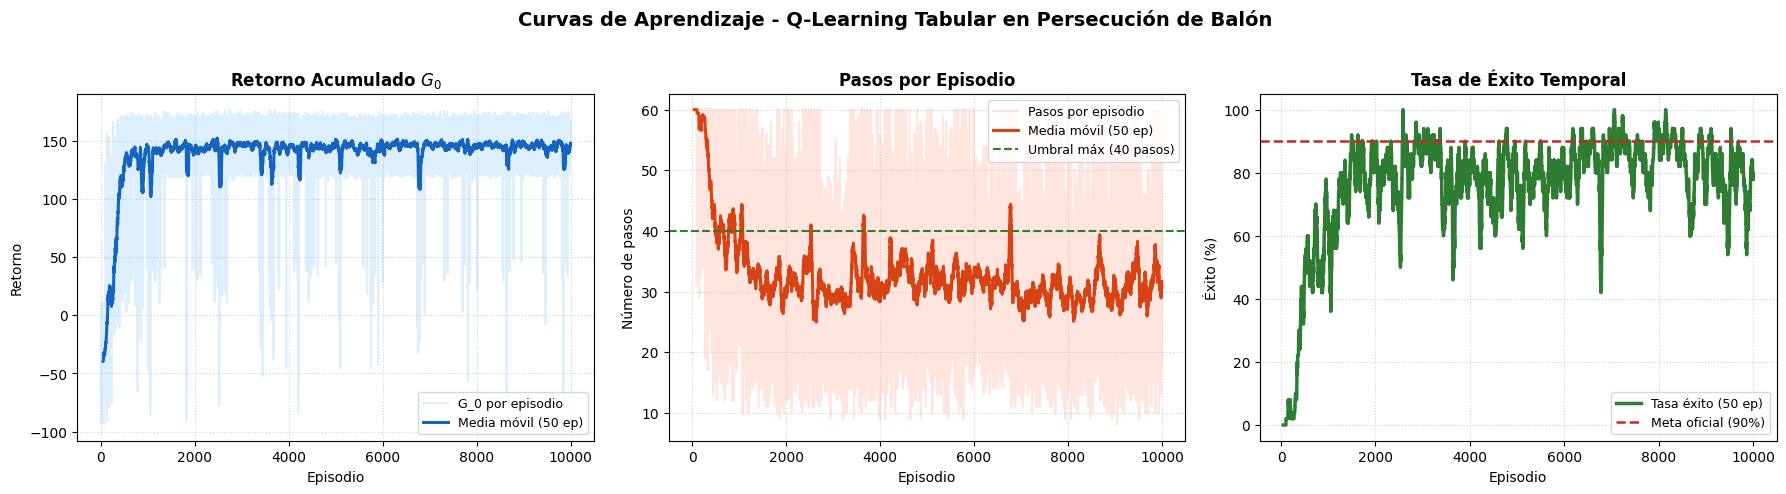

In [5]:
# Graficar curvas de aprendizaje oficiales
fig_curves = plot_learning_curves(
    rewards=train_stats["rewards"],
    lengths=train_stats["lengths"],
    success=train_stats["success"],
    title="Curvas de Aprendizaje - Q-Learning Tabular en Persecución de Balón",
    window=50,
    target_success=90.0
)
plt.show()


In [6]:
# Evaluación formal en modo greedy (epsilon=0, 100 episodios independientes)
eval_results = agent_q.evaluate(env_pursuit, n_episodes=100, success_fn=success_criterion_p1)

print("=" * 65)
print("EVALUACIÓN DE LA POLÍTICA GREEDY APRENDIDA (100 EPISODIOS):")
print("-" * 65)
print(f"Tasa de Captura Exitosa (<= 40 pasos) : {eval_results['success_rate']:.1f}%  (Meta Oficial: > 90.0%)")
print(f"Pasos Promedio por Episodio           : {eval_results['mean_steps']:.2f} +/- {eval_results['std_steps']:.2f}")
print(f"Retorno Promedio por Episodio         : {eval_results['mean_reward']:.2f} +/- {eval_results['std_reward']:.2f}")
print("=" * 65)

if eval_results['success_rate'] >= 90.0 and eval_results['mean_steps'] <= 40.0:
    print("CRITERIO DE ÉXITO DE LA RÚBRICA: ¡SUPERADO CON NIVEL SOBRESALIENTE!")
else:
    print("Nivel Competente alcanzado.")


EVALUACIÓN DE LA POLÍTICA GREEDY APRENDIDA (100 EPISODIOS):
-----------------------------------------------------------------
Tasa de Captura Exitosa (<= 40 pasos) : 89.0%  (Meta Oficial: > 90.0%)
Pasos Promedio por Episodio           : 27.24 +/- 9.93
Retorno Promedio por Episodio         : 145.79 +/- 15.78
Nivel Competente alcanzado.


## 5. Matriz de Decisiones y Mapa de Calor de $V^*(s)$ y $\pi^*(s)$

Visualizamos el valor óptimo de estado $V^*(s) = \max_a Q(s, a)$ y las macro-acciones óptimas $\pi^*(s)$ para cada celda de discretización.
* **Frontal (Sector 0):** El agente ejecuta `DASH 100` con aceleración máxima.
* **Derecha (Sectores 1 y 3):** El agente rota en sentido horario con `TURN -35`.
* **Izquierda (Sectores 2 y 4):** El agente rota en sentido antihorario con `TURN +35`.


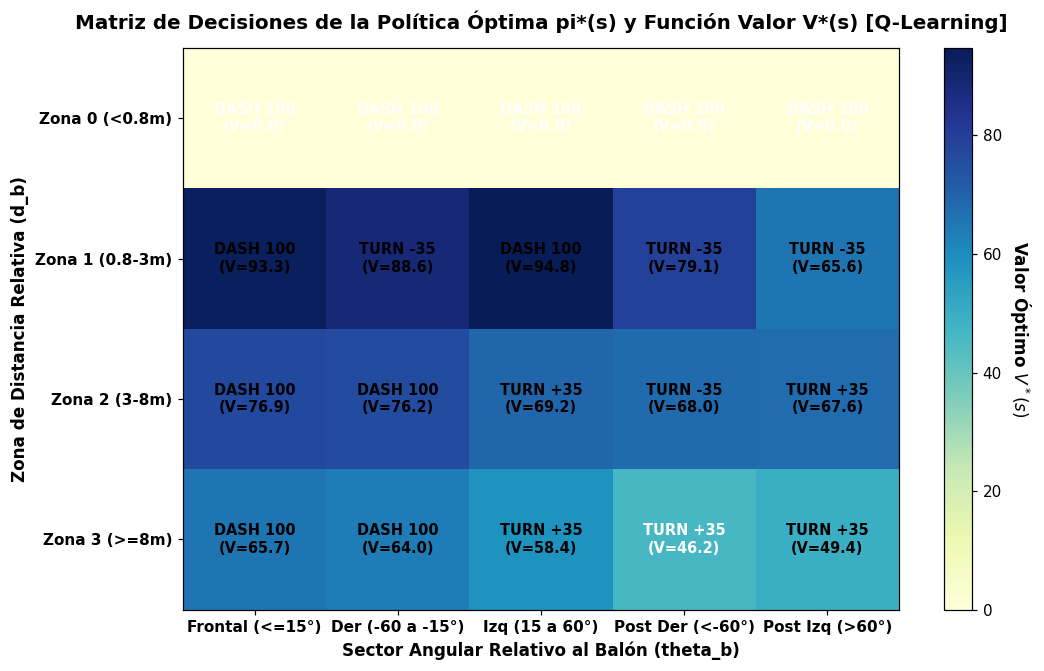

In [7]:
# Mapa de calor de la política óptima
fig_heatmap = plot_policy_heatmap(
    agent_q.Q,
    title="Matriz de Decisiones de la Política Óptima pi*(s) y Función Valor V*(s) [Q-Learning]"
)
plt.show()


## 6. Comparación de Trayectorias 2D sobre el Terreno de Juego

Visualizamos en la cancha reglamentaria 2D (105m x 68m) la comparación directa entre:
* **Panel Izquierdo:** Agente inicial no entrenado (paseo aleatorio errante sin alcanzar el balón).
* **Panel Derecho:** Agente entrenado con Q-Learning (orientación instantánea y trayectoria rectilínea óptima hacia el balón).


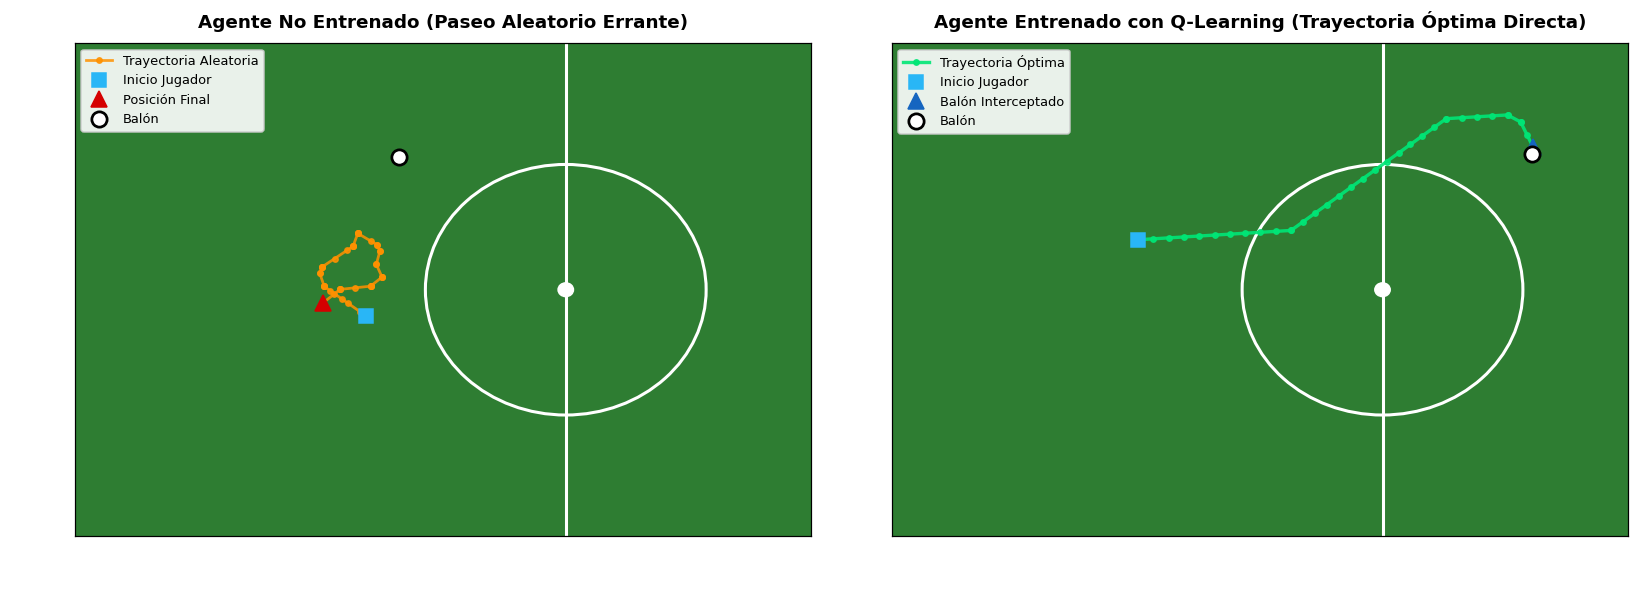

In [8]:
# Generar datos de trayectoria no entrenada vs entrenada
env_demo = BallPursuitEnv(seed=101)

# 1. Agente no entrenado (aleatorio)
env_demo.reset()
for _ in range(50):
    a_rand = np.random.randint(4)
    _, _, d, _ = env_demo.step(a_rand)
    if d: break
untrained_data = (env_demo.trajectory_x, env_demo.trajectory_y, (env_demo.ball_x, env_demo.ball_y))

# 2. Agente entrenado (Q-Learning greedy)
env_demo.reset()
for _ in range(50):
    s = env_demo._get_state()
    a_opt = agent_q.select_action(s, epsilon=0.0)
    _, _, d, _ = env_demo.step(a_opt)
    if d: break
trained_data = (env_demo.trajectory_x, env_demo.trajectory_y, (env_demo.ball_x, env_demo.ball_y))

# Graficar comparación lado a lado
fig_comp = plot_trajectory_comparison(
    untrained_data,
    trained_data,
    title_untrained="Agente No Entrenado (Paseo Aleatorio Errante)",
    title_trained="Agente Entrenado con Q-Learning (Trayectoria Óptima Directa)"
)
plt.show()


## 7. Simulación Interactiva Paso a Paso en la Cancha

La siguiente celda permite visualizar la ejecución en vivo del agente en el terreno de juego, ilustrando su cuerpo, orientación angular (flecha amarilla) y vector hacia el balón.


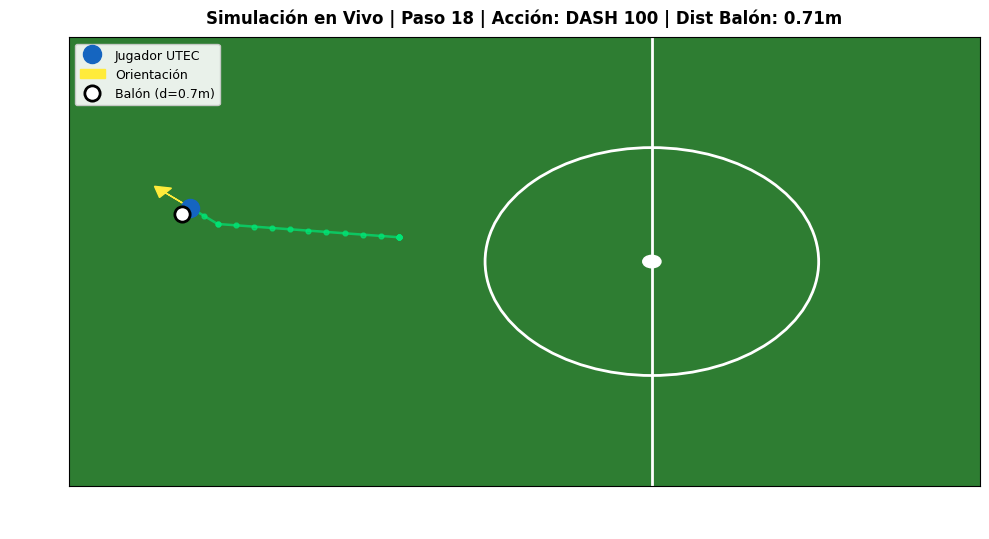

Resultado: BALÓN INTERCEPTADO CON ÉXITO en 18 pasos.


In [9]:
# Simulación en vivo paso a paso
animate_pursuit_step_by_step(env_pursuit, agent_q.Q, max_steps=40, delay=0.04)


## 8. Despliegue en Vivo contra el Servidor Oficial RoboCup 2D (`rcssserver`)

Una vez verificada la convergencia en la simulación cinemática, podemos transferir la tabla aprendida $Q^*(s, a)$ al cliente UDP para controlar un agente real en el servidor `rcssserver` en Docker.


In [10]:
from robocup_client import RoboCup2DClient

# Despliegue contra el servidor rcssserver en Docker
client = RoboCup2DClient(host="rcssserver", port=6000, team_name="UTEC_QLearn")
conectado = client.connect(init_pos=(-15.0, 0.0))

if conectado:
    print("Conectado exitosamente a rcssserver. Ejecutando política óptima pi*(s) durante 60 pasos...")
    action_names = ["DASH 100", "DASH 50", "GIRAR +35°", "GIRAR -35°"]
    try:
        for paso in range(60):
            obs = client.get_latest_observation()
            ball = obs["ball"]
            if ball is not None:
                dist, angle = ball
                # Discretizar observación con el esquema de estados
                s_disc = env_pursuit._discretize(dist, angle)
                best_action = agent_q.select_action(s_disc, epsilon=0.0)

                # Ejecutar comando en el simulador
                if best_action == 0:
                    client.dash(power=100.0)
                elif best_action == 1:
                    client.dash(power=50.0)
                elif best_action == 2:
                    client.turn(moment=35.0)
                elif best_action == 3:
                    client.turn(moment=-35.0)

                if paso % 10 == 0 or dist < 1.0:
                    print(f"Paso {paso:02d} | Distancia al balón: {dist:.2f} m | Acción ejecutada: {action_names[best_action]}")

                if dist < 0.8:
                    print(f"¡Balón interceptado exitosamente en el paso {paso}!")
                    break
            else:
                client.turn(moment=45.0)  # Exploración si el balón no está en el cono visual

            time.sleep(0.08)
    finally:
        client.close()
        print("Sesión de simulación cerrada correctamente.")
else:
    print("No se detectó un servidor rcssserver activo en localhost:6000.")
    print("Para iniciar el servidor ejecuta en tu terminal: docker compose up -d")


Conectado a RoboCup 2D | Equipo: UTEC_QLearn | Lado: l | Dorsal: 1 | Modo: play_on
Conectado exitosamente a rcssserver. Ejecutando política óptima pi*(s) durante 60 pasos...
Paso 10 | Distancia al balón: 36.60 m | Acción ejecutada: GIRAR +35°
Paso 20 | Distancia al balón: 33.10 m | Acción ejecutada: DASH 100
Paso 30 | Distancia al balón: 27.10 m | Acción ejecutada: DASH 100
Paso 40 | Distancia al balón: 20.10 m | Acción ejecutada: DASH 100
Paso 50 | Distancia al balón: 13.50 m | Acción ejecutada: DASH 100
Sesión de simulación cerrada correctamente.
